## Задание

Добейтесь на автокодировщике с 2-мерным скрытым пространством на 3-х цифрах: 0, 1 и 3 – ошибки MSE**<0.034** на скорости обучения **0.001** на **10-й эпохе**.

## Импорт библиотек


In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

%matplotlib inline

## Утилиты

Функция-коллбэк. Отрисовывает объекты в скрытом пространстве

In [ ]:
def ae_on_epoch_end(epoch, loss, encoder, X_train, y_train):
    print('________________________')
    print(f'*** ЭПОХА: {epoch+1}, loss: {loss:.6f} ***')
    print('________________________')

    plt.figure(dpi=100)

    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_train)
        predict = encoder(X_tensor).numpy()

    scatter = plt.scatter(predict[:, 0], predict[:, 1], c=y_train, alpha=0.6, s=5)
    plt.legend(*scatter.legend_elements(), loc='upper right', title='Классы')

    paths = glob.glob('*.jpg')
    plt.savefig(f'image_{str(len(paths))}.jpg')
    plt.show()

Удаление изображений. Применять при обучении новой модели, чтобы не было путаницы в картинках.

In [ ]:
def clean():
    paths = glob.glob('*.jpg')
    for p in paths:
        os.remove(p)

clean()

## Загрузка данных

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

X_train_full = train_dataset.data.numpy()
y_train_full = train_dataset.targets.numpy()
X_test = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.97MB/s]


In [ ]:
X_train_full = X_train_full.astype('float32') / 255.0
X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"Форма обучающей выборки: {X_train_full.shape}")
print(f"Форма тестовой выборки: {X_test.shape}")

Форма обучающей выборки: (60000, 28, 28, 1)
Форма тестовой выборки: (10000, 28, 28, 1)


In [ ]:
numbers = [0, 1, 3]
mask = np.array([(i in numbers) for i in y_train_full])
X_train = X_train_full[mask]
y_train = y_train_full[mask]

print(f"Выбрано {len(X_train)} изображений цифр 0, 1, 3")
print(f"Распределение классов: {np.unique(y_train, return_counts=True)}")

Выбрано 18796 изображений цифр 0, 1, 3
Распределение классов: (array([0, 1, 3]), array([5923, 6742, 6131]))


## Создание модели и обучение

In [ ]:
class Autoencoder2D(nn.Module):
    def __init__(self):
        super(Autoencoder2D, self).__init__()

        # Энкодер
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

        # Декодер
        self.decoder = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed, z

    def encode(self, x):
        return self.encoder(x)

model = Autoencoder2D()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

Autoencoder2D(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=784, bias=True)
    (7): Sigmoid()
  )
)


## Преобразовие в плоские вектора

In [ ]:
# Преобразование в плоские вектора (784)
X_train_flat = X_train.reshape(-1, 784)
X_train_tensor = torch.FloatTensor(X_train_flat)

train_dataset_tensor = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(train_dataset_tensor, batch_size=256, shuffle=True)

print(f"Форма данных: {X_train_tensor.shape}")
print(f"Готово: {len(train_loader)} батчей по 256 изображений")

Форма данных: torch.Size([18796, 784])
Готово: 74 батчей по 256 изображений


## Обучение модели

Эпоха 5/10, Loss: 0.031102
________________________
*** ЭПОХА: 5, loss: 0.031102 ***
________________________


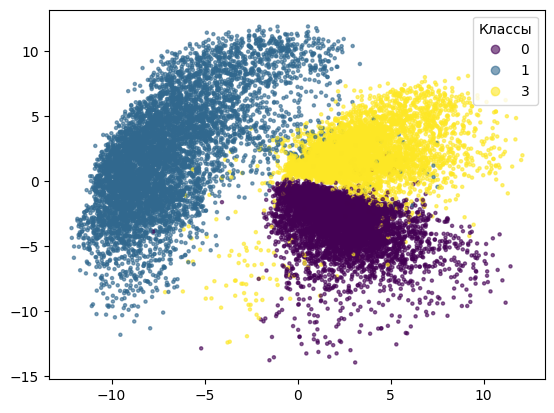

Эпоха 10/10, Loss: 0.028586
________________________
*** ЭПОХА: 10, loss: 0.028586 ***
________________________


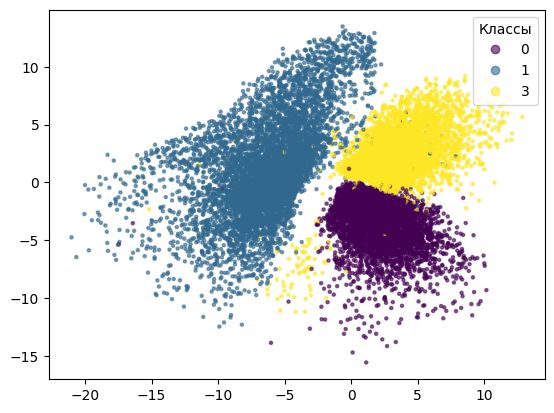

In [ ]:
epochs = 10
losses = []

for epoch in range(epochs):
    epoch_loss = 0.0
    model.train()

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        reconstructed, _ = model(batch_x)
        loss = criterion(reconstructed, batch_x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f'Эпоха {epoch+1}/{epochs}, Loss: {avg_loss:.6f}')
        ae_on_epoch_end(epoch, avg_loss, model.encode, X_train_flat, y_train)

## Вывод результатов

In [ ]:
model.eval()
with torch.no_grad():
    X_tensor = torch.FloatTensor(X_train_flat)
    reconstructed, _ = model(X_tensor)
    mse = torch.mean((X_tensor - reconstructed) ** 2).item()

print(f'MSE после {epochs} эпох: {mse:.6f}')

MSE после 10 эпох: 0.028146
